## 1. Setup & Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load Data

In [2]:
import os, glob, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

DATA_DIR = '/content/drive/MyDrive/MLMed Dataset/Lab 2/Data_2/'

TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'training_set')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test_set')

TRAIN_CSV = os.path.join(DATA_DIR, 'training_set_pixel_size_and_HC.csv')
TEST_CSV = os.path.join(DATA_DIR, 'test_set_pixel_size.csv')

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print('Training set shape:', train_df.shape)
print('Test set shape:', test_df.shape)
print()
print(train_df.head())

Training set shape: (999, 3)
Test set shape: (335, 2)

     filename  pixel size(mm)  head circumference (mm)
0  000_HC.png        0.069136                    44.30
1  001_HC.png        0.089659                    56.81
2  002_HC.png        0.062033                    68.75
3  003_HC.png        0.091291                    69.00
4  004_HC.png        0.061240                    59.81


## 3. EDA

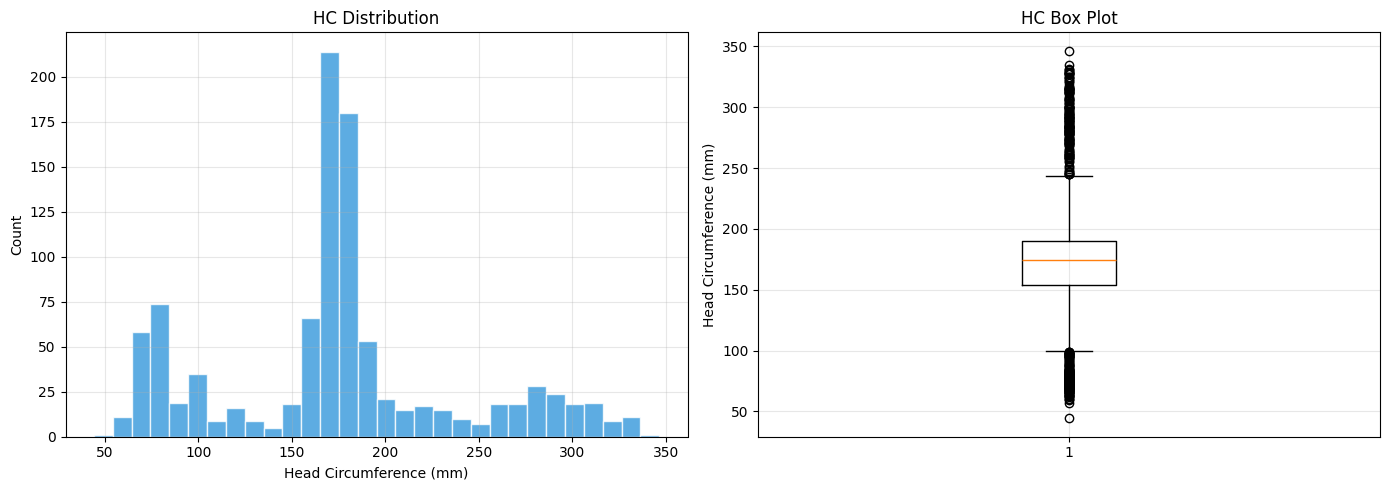

count    999.000000
mean     174.383093
std       65.282061
min       44.300000
25%      153.600000
50%      174.060000
75%      189.825000
max      346.400000
Name: head circumference (mm), dtype: float64


In [3]:
hc_col = [c for c in train_df.columns if 'circumference' in c.lower() or 'hc' in c.lower()][0]
fname_col = [c for c in train_df.columns if 'file' in c.lower() or 'name' in c.lower()][0]
fname_col_test = [c for c in test_df.columns if 'file' in c.lower() or 'name' in c.lower()][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df[hc_col], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('HC Distribution')
axes[0].set_xlabel('Head Circumference (mm)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(train_df[hc_col].dropna(), vert=True)
axes[1].set_title('HC Box Plot')
axes[1].set_ylabel('Head Circumference (mm)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(train_df[hc_col].describe())

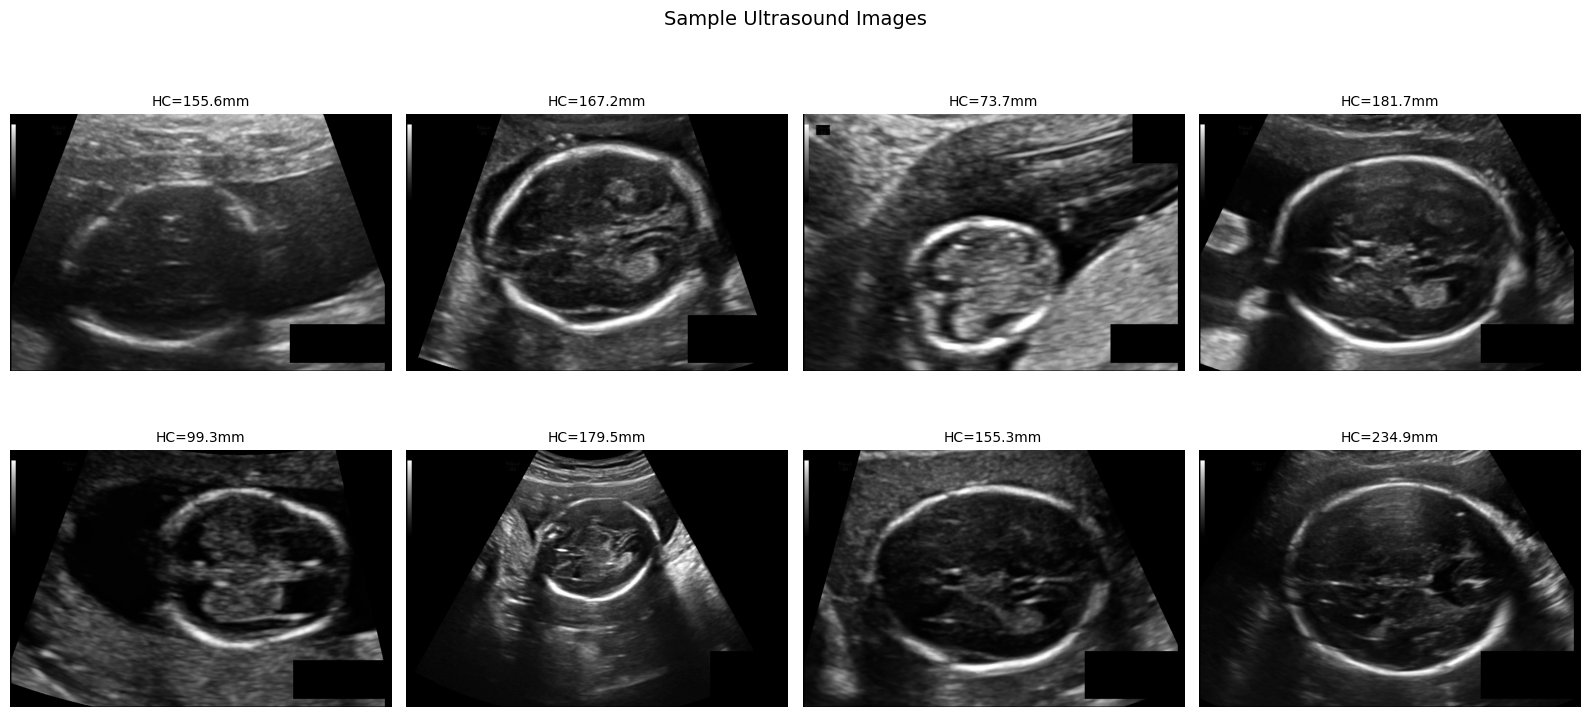

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_rows = train_df.sample(8, random_state=101)

for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    img_path = os.path.join(TRAIN_IMG_DIR, row[fname_col])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        ax.imshow(img, cmap='gray')
        ax.set_title(f'HC={row[hc_col]:.1f}mm', fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Ultrasound Images', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [5]:
IMG_SIZE = 224

def load_image(img_dir, fname):
    s = str(fname).strip().strip('"').strip("'")
    base = os.path.splitext(s)[0]
    paths = [
        os.path.join(img_dir, s),
        os.path.join(img_dir, base + '.png'),
        os.path.join(img_dir, base + '.PNG'),
    ]
    for p in paths:
        if os.path.exists(p):
            return p
    hits = glob.glob(os.path.join(img_dir, base + '.*'))
    return hits[0] if hits else None

X, y = [], []

for _, row in train_df.iterrows():
    path = load_image(TRAIN_IMG_DIR, row[fname_col])
    if path is None or pd.isna(row[hc_col]):
        continue
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    X.append(img)
    y.append(float(row[hc_col]))

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y, dtype=np.float32)

print('Total samples:', len(X))
print('X shape:', X.shape)
print('y range:', y.min(), '-', y.max())

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=101
)

Total samples: 999
X shape: (999, 224, 224, 1)
y range: 44.3 - 346.4


## 5. Model

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

inp = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))
x = layers.Lambda(lambda img: tf.image.grayscale_to_rgb(img))(inp)
x = tf.keras.applications.efficientnet.preprocess_input(x * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(1)(x)

model = models.Model(inp, out)

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss='mae',
    metrics=['mae']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,372 (16.11 MB)

 Trainable params: 172,545 (674.00 KB)

 Non-trainable params: 4,049,827 (15.45 MB)

## 6. Training

In [7]:
cb_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=7, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae', factor=0.5, patience=3, min_lr=1e-6
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 835ms/step - loss: 173.0785 - mae: 173.0785 - val_loss: 174.1070 - val_mae: 174.1070 - learning_rate: 5.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 168.2277 - mae: 168.2277 - val_loss: 167.1057 - val_mae: 167.1057 - learning_rate: 5.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 160.0441 - mae: 160.0441 - val_loss: 152.7971 - val_mae: 152.7971 - learning_rate: 5.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 144.5450 - mae: 144.5450 - val_loss: 126.9627 - val_mae: 126.9627 - learning_rate: 5.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 119.0171 - mae: 119.0171 - val_loss: 90.7803 - val_mae: 90.7803 - learning_rate: 5.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 88.8334 - mae: 88.8334 - val_loss: 64.6418 - val_mae: 64.6418 - learning_rate: 5.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 72.5044 - mae: 72.5044 - va

## 7. Evaluation

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_val).reshape(-1)

mae_val = mean_absolute_error(y_val, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred))
r2_val = r2_score(y_val, y_pred)

print(f'MAE:  {mae_val:.2f} mm')
print(f'RMSE: {rmse_val:.2f} mm')
print(f'R2:   {r2_val:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step
MAE:  16.34 mm
RMSE: 21.82 mm
R2:   0.8863


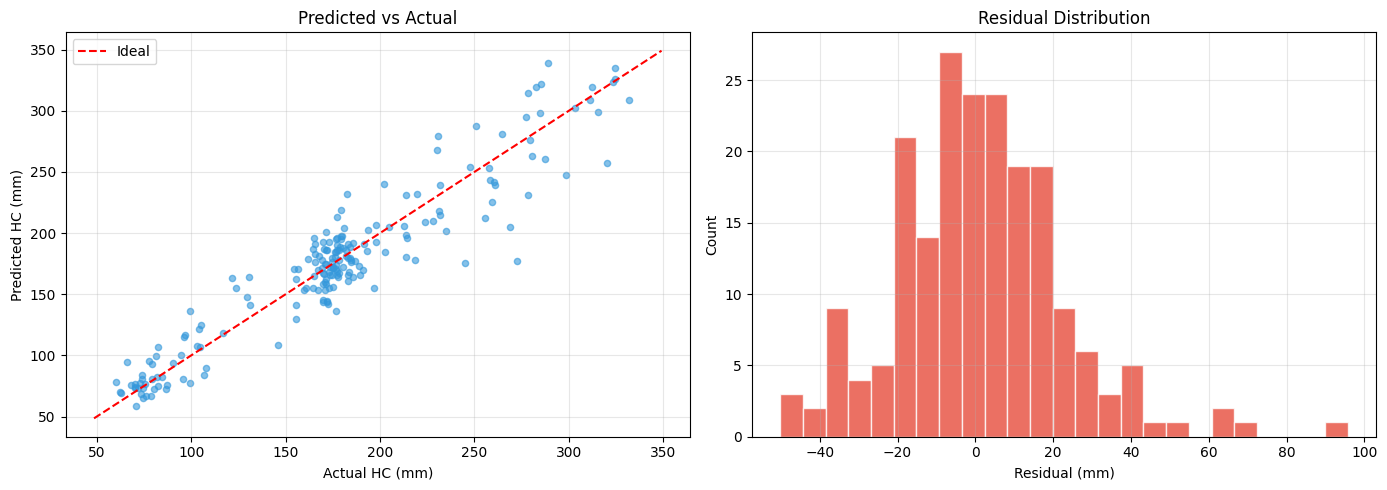

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val, y_pred, alpha=0.6, color='#3498db', s=20)
lims = [min(y_val.min(), y_pred.min()) - 10, max(y_val.max(), y_pred.max()) + 10]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')
axes[0].set_xlabel('Actual HC (mm)')
axes[0].set_ylabel('Predicted HC (mm)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_val - y_pred
axes[1].hist(residuals, bins=25, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual (mm)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

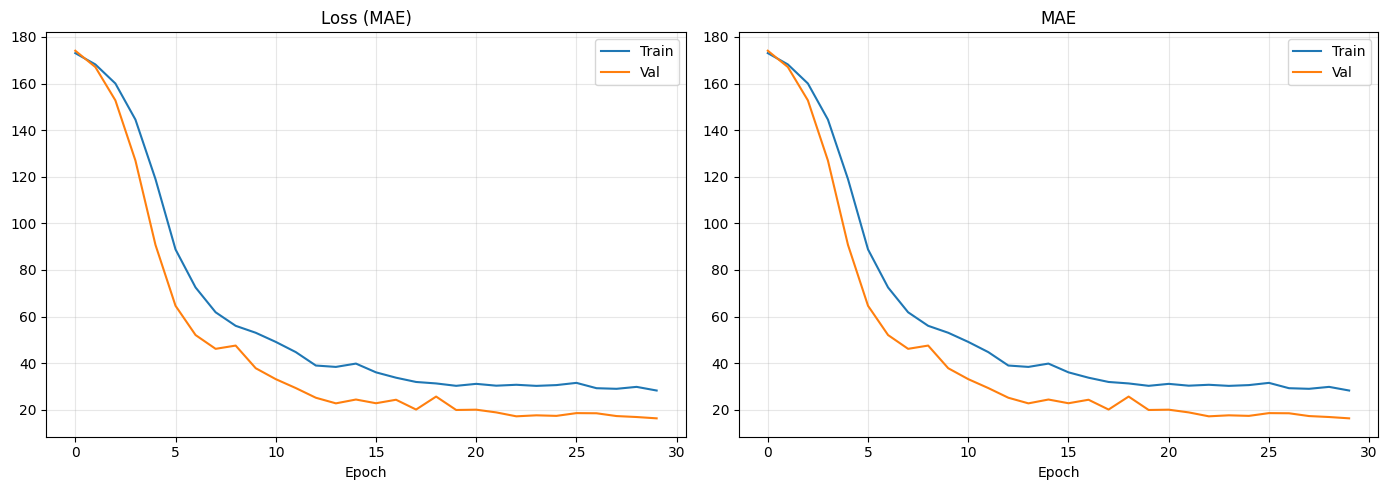

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss (MAE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Test Prediction

In [11]:
X_test, test_names = [], []

for _, row in test_df.iterrows():
    path = load_image(TEST_IMG_DIR, row[fname_col_test])
    if path is None:
        continue
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    X_test.append(img)
    test_names.append(row[fname_col_test])

X_test = np.array(X_test).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

test_preds = model.predict(X_test).reshape(-1)

submit_df = pd.DataFrame({'filename': test_names, 'HC': test_preds})
submit_df.to_csv(os.path.join(DATA_DIR, 'submission_prac2.csv'), index=False)

print(submit_df.head(10))

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 463ms/step
     filename          HC
0  000_HC.png  295.849487
1  001_HC.png   73.275673
2  002_HC.png  186.050873
3  003_HC.png  212.443359
4  004_HC.png  309.339508
5  005_HC.png  171.076843
6  006_HC.png  198.471558
7  007_HC.png  180.208588
8  008_HC.png  211.928848
9  009_HC.png  325.530060
